In [1]:
import base64
import requests

# Simple example

In [2]:
with open("data/grape/images/train/pd_train_train_00021.jpg", "rb") as f:
    img_b64 = base64.b64encode(f.read()).decode("utf-8")

payload = {
    "dataframe_records": [
        {"image": [img_b64]}
    ]
}

res = requests.post("http://localhost:5001/invocations", json=payload)
print(res.json())

{'predictions': [2]}


# Let's try with more images

In [14]:
import os
import pandas as pd

records = []
raw_val_image = []

image_val_path = 'data/grape/images/val/'
label_val_path = 'data/grape/labels/val/'

for image_name in os.listdir(image_val_path):
    with open(image_val_path + image_name, "rb") as f:
        raw_val_image.append(base64.b64encode(f.read()).decode("utf-8"))

    label_name = image_name.replace('.jpg', ".txt")
    with open(label_val_path + label_name, "r") as f:
        label = f.read()
    records.append({
        "file_name": image_name,
        "class": label[0]
    })

df_val = pd.DataFrame(records, columns=['file_name', 'class']) 

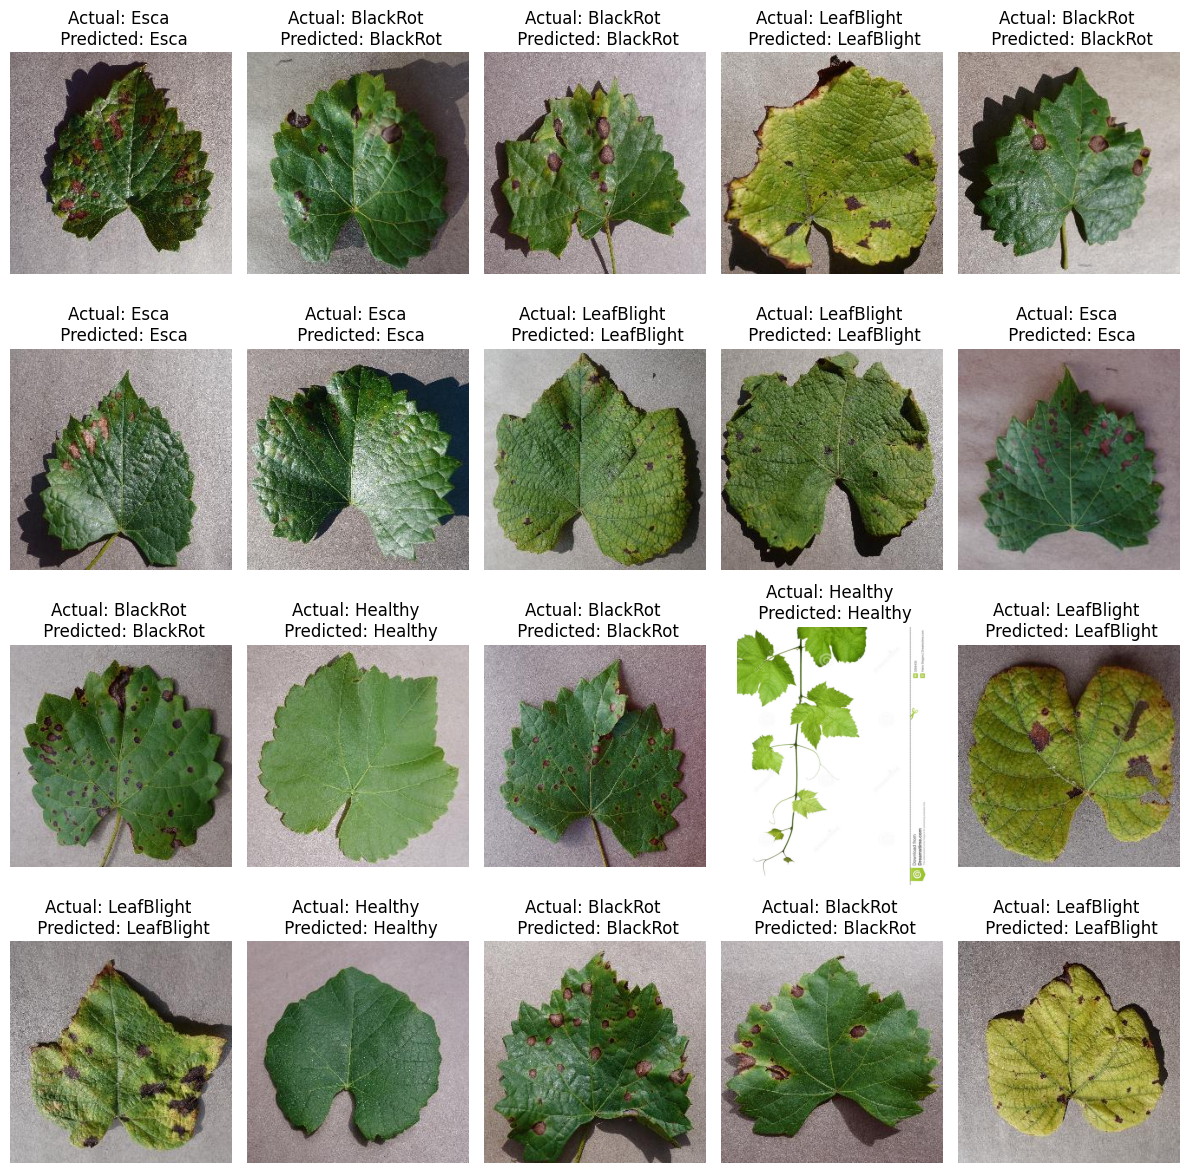

In [28]:
from io import BytesIO
import matplotlib.pyplot as plt
from PIL import Image 
from IPython.display import clear_output, display
import random

random_indices = random.sample(range(len(df_val)), 20)
images = []
predictions = []
class_map = {0: 'BlackRot', 1:'Esca', 2:'Healthy', 3:'LeafBlight'}

for i, idx in enumerate(random_indices):    
    payload = {
    "dataframe_records": [
        {"image": [raw_val_image[idx]]}
        ]
    }
    res = requests.post("http://localhost:5001/invocations", json=payload)
    predictions.append(res.json()['predictions'][0])
    img_data = base64.b64decode(raw_val_image[idx])
    img = Image.open(BytesIO(img_data))
    images.append((img, int(df_val.iloc[idx]['class'])))
                 
    clear_output(wait=True) 

    # IMPORTANT: create a fresh figure EACH time
    fig, axes = plt.subplots(
        nrows=(len(images) + 4) // 5,
        ncols=5,
        figsize=(12, 12)
    )

    axes = axes.flatten()
    
    for j, (im, meta) in enumerate(images):
        axes[j].imshow(im)
        axes[j].set_title(f'Actual: {class_map[meta]} \n Predicted: {class_map[predictions[j]]}')
        axes[j].axis("off")

    # hide unused subplots
    for k in range(len(images), len(axes)):
        axes[k].axis("off")

    plt.tight_layout()
    display(fig)
    plt.close(fig)  

plt.show()